# Testing Notebook

# Ignore Trainig and Validation Accuracy, those are not objective truth measruements they are more just a guage to see how far the model is from the actual postion of the car
# Also ignore those metrics for the funciton reportFinalMetrics

In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import config as cfg
import os

import torch
from torch import nn
from torch.utils.data import DataLoader

from Data.data_loading import load_and_preprocess_data, create_tensor_from_dataframe, create_sequences, create_dataloaders 
from Training.train_matt import Trainer
from Training.basicEval import plotLoss, plotAccuracy, reportFinalMetrics, reportMultiFinalMetrics, plotMultiAccuracy, plotMultiLoss
from Model.model_split import FrameTransformer, print_model_info

from Training.customLoss import ADELoss, FDELoss, RMSELoss

Using GPU


W0505 12:39:24.623000 11288 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
root_dir = os.getcwd()  # Use current working directory as root
data_dir = os.path.join(root_dir, 'Data')
csv_dir = os.path.join(data_dir, 'csv')
csv_file = os.path.join(csv_dir, 'trimmed_IMG_4097_detections.csv')

print("Data directory: ", data_dir)
print("CSV directory: ", csv_dir)
print("CSV file: ", csv_file)


model_dir = os.path.join(root_dir, 'Model')
save_model_dir = os.path.join(model_dir, 'Saved_Model')
print("Model directory: ", model_dir)
print("Saved model directory: ", save_model_dir)


Data directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data
CSV directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data\csv
CSV file:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data\csv\trimmed_IMG_4097_detections.csv
Model directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model
Saved model directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model\Saved_Model


In [3]:
ADE = ADELoss()
FDE = FDELoss()
RMSE = RMSELoss()

In [4]:
df, transformer_max_ids_per_frame, frame_scaler = load_and_preprocess_data(csv_folder=csv_dir)

# 2. Create tensor from dataframe
all_data_tensor = create_tensor_from_dataframe(df, transformer_max_ids_per_frame)

# 3. Create input-output sequences
X, Y = create_sequences(all_data_tensor)

# 4. Create dataloaders for training and testing
train_loader, test_loader, train_prefetcher, test_prefetcher = create_dataloaders(X, Y)


All CSVs now have 599 frames after trimming
Minimum records per ID: 3
Average records per ID: 1763.55
Maximum records per ID: 3209

Minimum IDs (Vehicles) per frame: 5
Average IDs (Vehicles) per frame: 14.34
Maximum IDs (Vehicles) per frame: 20

After normalization:
X range: 0.0000 to 5.0000
Y range: 0.0000 to 5.0000
Height range: 0.0000 to 5.0000
Width range: 0.0000 to 5.0000
Frame range: 0.0000 to 5.0000
All data tensor shape: torch.Size([6, 599, 20, 5])


# RMSE 1 Second


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

...

Epoch 49/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 49/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 50/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


Training complete in 259.23 seconds, or 4.32 minutes
Total epochs run: 50
Average time per epoch: 5.18 seconds
Inference time per batch: 0.07 seconds
Final Training Loss: 0.6864
Final Validation Loss: 0.7191
Final Training Accuracy: 90.49%
Final Validation Accuracy: 90.68%


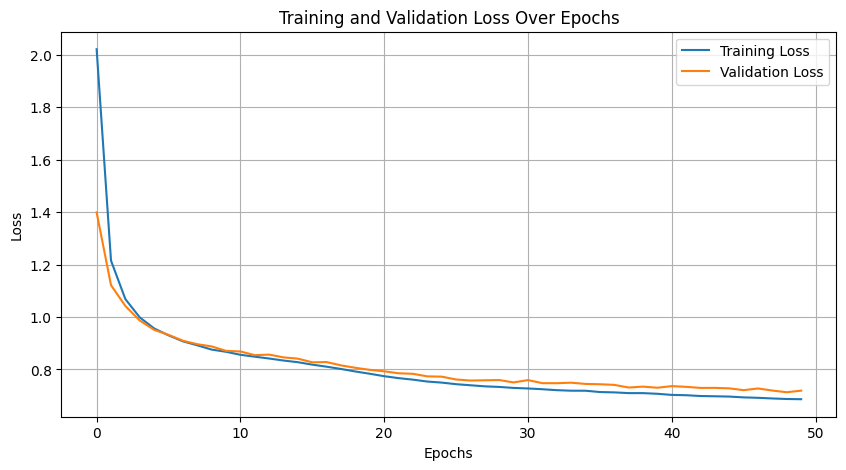

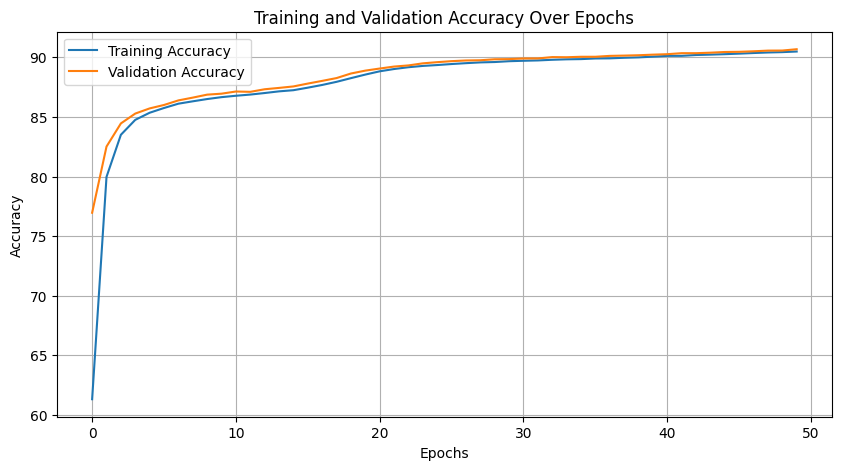

Final Training Accuracy: 0.69%
Final Validation Accuracy: 0.72%
Final Training Loss: 90.4873
Final Validation Loss: 90.6800
Total Training Time: 259.20 seconds


In [5]:
cfg.PREDICTION_LENGTH = 30 # 1 Second

# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=RMSE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)

plotLoss(train_losses4, val_losses4)
plotAccuracy(train_accs4, val_accs4)
reportFinalMetrics(train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4)

# RMSE 2 Seconds

In [6]:
cfg.PREDICTION_LENGTH = 60 # 2 Second

# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=RMSE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)

plotLoss(train_losses4, val_losses4)
plotAccuracy(train_accs4, val_accs4)
reportFinalMetrics(train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4)


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

C:\Users\flyer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([32, 30, 20, 2])) that is different to the input size (torch.Size([32, 60, 20, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (60) must match the size of tensor b (30) at non-singleton dimension 1

# RMSE 3 Seconds

In [7]:
cfg.PREDICTION_LENGTH = 90 # 3 Second

# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=RMSE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)

plotLoss(train_losses4, val_losses4)
plotAccuracy(train_accs4, val_accs4)
reportFinalMetrics(train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4)


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

C:\Users\flyer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([32, 30, 20, 2])) that is different to the input size (torch.Size([32, 90, 20, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (90) must match the size of tensor b (30) at non-singleton dimension 1

# RMSE 4 Seconds

In [8]:
cfg.PREDICTION_LENGTH = 120 # 4 Second

# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=RMSE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)

plotLoss(train_losses4, val_losses4)
plotAccuracy(train_accs4, val_accs4)
reportFinalMetrics(train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4)


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

C:\Users\flyer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([32, 30, 20, 2])) that is different to the input size (torch.Size([32, 120, 20, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (120) must match the size of tensor b (30) at non-singleton dimension 1